In [1]:
import numpy as np
import matplotlib.pyplot as plt

# AWS imports: Import Braket SDK modules
from braket.circuits import Circuit, Gate, Observable
from braket.devices import LocalSimulator
from braket.aws import AwsDevice, AwsQuantumTask
from braket.tracking import Tracker

from utils import *
from scipy.sparse import diags
from scipy.sparse.linalg import expm_multiply
from scipy.sparse import lil_matrix, diags, kron
plt.rcParams['figure.facecolor']='white'

In [2]:
tracker = Tracker().start()

In [3]:
# the IonQ device
device = AwsDevice("arn:aws:braket:::device/qpu/ionq/ionQdevice")
supported_gates = device.properties.action['braket.ir.jaqcd.program'].supportedOperations
# print the supported gate set
print('Gate set supported by the IonQ device:\n', supported_gates)
print('\n') 

Gate set supported by the IonQ device:
 ['x', 'y', 'z', 'rx', 'ry', 'rz', 'h', 'cnot', 's', 'si', 't', 'ti', 'v', 'vi', 'xx', 'yy', 'zz', 'swap']




In [4]:
# Returns the codewords using unary embedding
def get_codewords_1d_unary(n : int):
    
    codewords = []

    bitstring = [0 for k in range(n)]
    for i in range(n+1):

        codewords.append(np.copy(bitstring))

        if i < n:
            bitstring[i] = 1 - bitstring[i]

    return codewords

def get_codewords_2d_unary(n : int):
    
    codewords = []

    bitstring_1 = [0 for k in range(n)]
    for i in range(n+1):

        bitstring_2 = [0 for k in range(n)]
        for j in range(n+1):

            full_bitstring = np.concatenate([bitstring_1, bitstring_2])
            codewords.append(full_bitstring)

            if j < n:
                bitstring_2[j] = 1 - bitstring_2[j]

        if i < n:
            bitstring_1[i] = 1 - bitstring_1[i]

    return codewords

In [5]:
encoding = "unary"

In [294]:
N = 6
if encoding == "unary":
    n = N-1
# m = 10
L = 0
R = 1

h = (R-L)/(N-1)
# omega = (m * h) ** (1/2)

# T = 2.0
# N_t = 64
# times = np.linspace(0, T, N_t)

x, p = np.meshgrid(np.linspace(L, R, N), np.linspace(L, R, N), indexing='ij')
# X = np.stack([x0_tmp,x1_tmp], axis=-1)
x_vals = np.linspace(L, R, N)
p_vals = np.linspace(L, R, N)

Here we consider the following PDE with 2 spatial variables:
$$
    \frac{\partial u}{\partial t} + x_2 \frac{\partial u}{\partial x_1} - x_1 \frac{\partial u}{\partial x_2} = 0.
$$

Let $q_1,\dots,q_{N}$ denote the $N$ grid points.

The resulting Hamiltonian has the form
$$
    -i \begin{pmatrix}
    0 & 1 & 0 & 0\\
    -1 & 0 & \ddots & 0\\
    0 & \ddots & 0 & 1 \\
    0 & 0 & -1 & 0
    \end{pmatrix} \otimes
    \textrm{diag}(\hat{q}_1,\hat{q}_2,\dots,\hat{q}_{N}) -
    \textrm{diag}(\hat{q}_1,\hat{q}_2,\dots,\hat{q}_{N})\otimes
    -i\begin{pmatrix}
    0 & 1 & 0 & 0\\
    -1 & 0 & \ddots & 0\\
    0 & \ddots & 0 & 1 \\
    0 & 0 & -1 & 0
    \end{pmatrix}.
$$

In [295]:
PROJ_0 = (IDENTITY + PAULI_Z) / 2
PROJ_1 = (IDENTITY - PAULI_Z) / 2

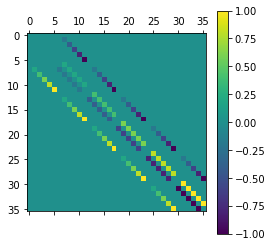

In [296]:
P = -1j * diags([np.ones(n), -np.ones(n)], offsets=[1,-1])

H = kron(-diags(p_vals), P) + kron(P, diags(x_vals))

plt.matshow(H.toarray().imag)
plt.colorbar()
plt.show()

In [297]:
H_full = csc_matrix((2 ** (2 * n), 2 ** (2 * n)))

# x_2 \partial_{x_1} u
for i in range(n):

    # In general, the coefficient could also depend on x_1
    operators = []
    
    for j in range(n-i-1):
        operators.append(IDENTITY)

    if encoding == "unary":
        operators.append(PAULI_Y)
    else:
        operators.append(((-1) ** i) * PAULI_Y)
    
    for j in range(i):
        operators.append(IDENTITY)

    # Control part

    # Bitstring where bit i is 1 if we control on it
    control_bitstring = np.zeros(n)
    control_bitstring[0] = 1
    control_bitstring[-1] = 1 


    for k in range(n+1):

        # Control on chain for x_2
        control_operators = []

        for l in range(n):

            # AFM
            if k % 2 == 0:
                PROJ = PROJ_0
            else:
                PROJ = PROJ_1

            # Unary
            if l - k >= 0:
                PROJ = PROJ_0
            else:
                PROJ = PROJ_1
                
            control_operators.insert(0, (1 - control_bitstring[l]) * IDENTITY + control_bitstring[l] * PROJ)

        control_bitstring[k-1] = 1 - control_bitstring[k-1]
        control_bitstring[(k+1) % n] = 1 - control_bitstring[(k+1) % n]

        H_full += kron(p_vals[k] * tensor(control_operators), tensor(operators))

        H_full += kron(tensor(operators), -x_vals[k] * tensor(control_operators))


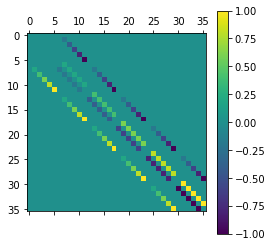

In [298]:
C = get_codewords_2d_unary(n)


H_subspace = np.zeros((N ** 2, N ** 2), dtype=np.complex64)

for i in range(N ** 2):
    index_1 = bitstring_to_int(C[i])

    for j in range(N ** 2):
        index_2 = bitstring_to_int(C[j])
        H_subspace[i,j] = H_full[index_1, index_2]

plt.matshow(H_subspace.imag)
plt.colorbar()
plt.show()

We estimate the gate count for doing the two-dimensional PDE via Hamiltonian embedding.



For the unary embedding, the perturbation Hamiltonian for $x_2 \frac{\partial u}{\partial x_1}$ is

$$
    H = \frac{1}{2h}\sum_{\ell=1}^{N} q_{\ell} \mathrm{Proj}_{\text{Unary}}^{(2)}(\ell)\sum_{k=1}^{n} Y_k^{(1)}
$$

Similarly, the perturbation Hamiltonian for $-x_1 \frac{\partial u}{\partial x_2}$ is

$$
    H = -\frac{1}{2h}\sum_{\ell=1}^{N} q_{\ell} \mathrm{Proj}_{\text{Unary}}^{(1)}(\ell)\sum_{k=1}^{n} Y_k^{(2)}
$$


In [299]:
# modify to use mat2qubit later

# x_2 (\partial u / \partial x_1)
# coefficient of sum of Y on qubits for x_1
Y_terms = 0
# sum of Y on qubits for x_1, Z on qubits for x_2
YZ_terms = np.zeros(n)
# sum of Y on qubits for x_1, ZZ on qubits for x_2
YZZ_terms = np.zeros(n)

# Bitstring where bit i is 1 if we control on it
control_bitstring = np.zeros(n)
control_bitstring[0] = 1
control_bitstring[-1] = 1 

for k in range(N):
    Y_terms += (1/4) * x_vals[k]

    for l in [(k-1) % n, k % n]:
        # Unary
        if l - k >= 0:
            # projector onto zero
            YZ_terms[l] += (1/4) * x_vals[k]
        else:
            # projector onto one
            YZ_terms[l] -= (1/4) * x_vals[k]
    
    if k == 0 or k == N-1:
        YZZ_terms[k % n] += (1/4) * x_vals[k]
    else:
        YZZ_terms[k % n] -= (1/4) * x_vals[k]


We verify that this is the correct Pauli decomposition.

In [300]:
def sum_J_yz(n : int, J : np.ndarray) -> np.ndarray:
    # row of J is for Pauli Z, column is for Pauli Y
    # J_{i,j} is coefficient of Z_i Y_j
    assert n > 0
    assert J.shape == (n,n)

    dims = [2 ** i for i in range(n)]

    res = csc_matrix((2 ** n, 2 ** n))
    for i in range(n):
        for j in range(i):
            res += J[i,j] * tensor([identity(dims[n-i-1], format='csr'), PAULI_Z, identity(dims[i-j-1], format='csr'), PAULI_Y, identity(dims[j], format='csr')])
            
    for j in range(n):
        for i in range(j):
            res += J[i,j] * tensor([identity(dims[n-j-1], format='csr'), PAULI_Y, identity(dims[j-i-1], format='csr'), PAULI_Z, identity(dims[i], format='csr')])
            
    return res

def sum_J_yzz(n : int, J : np.ndarray) -> np.ndarray:
    # J_{i,j,k} is coefficient of Z_i Z_j Y_k
    assert n > 0
    assert J.shape == (n,n,n)

    dims = [2 ** i for i in range(n)]

    res = csc_matrix((2 ** n, 2 ** n))
    # i > j > k
    for i in range(n):
        for j in range(i):
            for k in range(j):
                res += J[i,j,k] * tensor([identity(dims[n-i-1], format='csr'), PAULI_Z, identity(dims[i-j-1], format='csr'), PAULI_Z, identity(dims[j-k-1], format='csr'), PAULI_Y, identity(dims[k], format='csr')])
    # i > k > j
    for i in range(n):
        for k in range(i):
            for j in range(k):
                res += J[i,j,k] * tensor([identity(dims[n-i-1], format='csr'), PAULI_Z, identity(dims[i-k-1], format='csr'), PAULI_Y, identity(dims[k-j-1], format='csr'), PAULI_Z, identity(dims[j], format='csr')])
    # j > i > k 
    for j in range(n):
        for i in range(j):
            for k in range(i):
                res += J[i,j,k] * tensor([identity(dims[n-j-1], format='csr'), PAULI_Z, identity(dims[j-i-1], format='csr'), PAULI_Z, identity(dims[i-k-1], format='csr'), PAULI_Y, identity(dims[k], format='csr')])
    # j > k > i
    for j in range(n):
        for k in range(j):
            for i in range(k):
                res += J[i,j,k] * tensor([identity(dims[n-j-1], format='csr'), PAULI_Z, identity(dims[j-k-1], format='csr'), PAULI_Y, identity(dims[k-i-1], format='csr'), PAULI_Z, identity(dims[i], format='csr')])
    # k > i > j
    for k in range(n):
        for i in range(k):
            for j in range(i):
                res += J[i,j,k] * tensor([identity(dims[n-k-1], format='csr'), PAULI_Y, identity(dims[k-i-1], format='csr'), PAULI_Z, identity(dims[i-j-1], format='csr'), PAULI_Z, identity(dims[j], format='csr')])
   
    # k > j > i
    for k in range(n):
        for j in range(k):
            for i in range(j):
                res += J[i,j,k] * tensor([identity(dims[n-k-1], format='csr'), PAULI_Y, identity(dims[k-j-1], format='csr'), PAULI_Z, identity(dims[j-i-1], format='csr'), PAULI_Z, identity(dims[i], format='csr')])
    return res

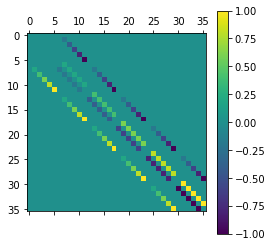

In [301]:

# Y terms
H_1 = sum_h_y(2 * n, np.concatenate([Y_terms * np.ones(n), np.zeros(n)]))
H_2 = sum_h_y(2 * n, np.concatenate([np.zeros(n), Y_terms * np.ones(n)]))

# YZ terms
J = np.zeros((2 * n, 2 * n))
for i in np.arange(n):
    J[n+i,0:n] += YZ_terms[i]
H_1 += sum_J_yz(2 * n, J)

J = np.zeros((2 * n, 2 * n))
for i in np.arange(n):
    J[i,n:2*n] += YZ_terms[i]
H_2 += sum_J_yz(2 * n, J)

# YZZ terms
J = np.zeros((2 * n, 2 * n, 2 * n))
for i in range(n):
    J[n+i, n + ((i-1) % n), 0:n] += YZZ_terms[i]
H_1 += sum_J_yzz(2 * n, J)

J = np.zeros((2 * n, 2 * n, 2 * n))
for i in range(n):
    J[i, (i-1) % n, n:2*n] += YZZ_terms[i]
H_2 += sum_J_yzz(2 * n, J)

H_full = H_1 - H_2

C = get_codewords_2d_unary(n)

H_subspace = np.zeros((N ** 2, N ** 2), dtype=np.complex64)

for i in range(N ** 2):
    index_1 = bitstring_to_int(C[i])

    for j in range(N ** 2):
        index_2 = bitstring_to_int(C[j])
        H_subspace[i,j] = H_full[index_1, index_2]

plt.matshow(H_subspace.imag)
plt.colorbar()
plt.show()

In [302]:
use_real_machine = False

if use_real_machine:
    device = AwsDevice("arn:aws:braket:::device/qpu/ionq/ionQdevice")
else:
    # set up device: Local Simulator
    device = LocalSimulator()

print(f"Using {device.name}")

Using StateVectorSimulator


In [304]:
def get_circuit(n, T, num_layers, R):
    h = 1 / n
    circuit = Circuit()

    # 0,...,n-1 for x_1
    # n,...,2n-1 for x_2
    # 2n,...,2n + n^2 - 1 for auxiliary qubits (controls on x_1)
    # 2n + n^2,...,2n + 2n^2 - 1 for auxiliary qubits (controls on x_2)
    for i in range(num_layers):
        # sum of Pauli-y
        circuit.ry(np.arange(0, n), Y_terms * T / (num_layers * h))
        circuit.ry(np.arange(n, 2 * n), -Y_terms * T / (num_layers * h))

        print(circuit.depth)
        for j in np.arange(n, 2 * n):
            for k in np.arange(n):
                # Needs to be modified to ZY (with MS gate)
                circuit.yy(j, k, YZ_terms[k] * T / (num_layers * h))
                circuit.yy(k, j, -YZ_terms[j % n] * T / (num_layers * h))

        # penalty part on ancilla
        for j in range(n ** 2):
            for k in range(j):
                circuit.zz(2 * n + j, 2 * n + k, - 2 * T * R / num_layers)
                circuit.zz(2 * n + n ** 2 + j, 2 * n + n ** 2 + k, - 2 * T * R / num_layers)
        
        # penalty part for unary encoding
        circuit.rz(0, 2 * T * R / num_layers)
        circuit.rz(n-1, -2 * T * R / num_layers)
        for j in np.arange(0, n-1, 2):
            circuit.zz(j, j+1, - 2 * T * R / num_layers)
        for j in np.arange(1, n-1, 2):
            circuit.zz(j, j+1, - 2 * T * R / num_layers)
        
        # ZZY terms
        for j in np.arange(n, 2 * n):
            for k in np.arange(n):

                aux_index_1 = n * (j - n) + k + 2 * n
                aux_index_2 = n * (j - n) + (k - 1) % n + 2 * n + n ** 2

                # Decompose into XY and XZ
                # Control on x_2
                circuit.yy(aux_index_1, j, T / (num_layers * h))
                circuit.yy(aux_index_1, (j-1) % n + n, T / (num_layers * h))
                circuit.yy(aux_index_1, k, YZZ_terms[k % n] * T / (num_layers * h))
                # Control on x_1
                circuit.yy(aux_index_2, k, T / (num_layers * h))
                circuit.yy(aux_index_2, (k-1) % n + n, T / (num_layers * h))
                circuit.yy(aux_index_2, j, YZZ_terms[j % n] * T / (num_layers * h))

    return circuit

def decode_unary(n, bitstring):
    flips = 0
    first_flip = 0
    for i in range(n-1):
        if bitstring[i] != bitstring[i+1]:
            flips += 1
            first_flip = i
    
    if flips >= 2 or (bitstring[0] == 0 and flips == 1):
        return -1
    else:
        if flips == 0:
            if bitstring[0] == 0:
                return 0
            else:
                return n
        elif flips == 1:
            return first_flip + 1

In [305]:
T = 0.1
num_layers = 1

In [307]:

circuit = get_circuit(n, T, num_layers, R = 1)
print(f"Circuit depth: {circuit.depth}")

1
Circuit depth: 171


In [180]:
num_shots = 100
task = device.run(circuit, shots=num_shots)

result = task.result()

counts = result.measurement_counts

In [181]:
def get_occurrences(n : int, measurements, num_shots : int):
    occurrences = np.zeros(n+1)
    # occurrences = np.zeros((4,n+1))
    bad_samples = 0
    for i in range(num_shots):
        bitstring = measurements[i]
                
        index = decode_unary(n, bitstring)
        if index >= 0:
            occurrences[index] += 1
                
    print(f"Samples in codeword subspace: {int(np.sum(occurrences))} / {num_shots}")

    return occurrences

In [182]:
occurrences = get_occurrences(n, result.measurements, num_shots=num_shots)
dist = occurrences / np.sum(occurrences)

Samples in codeword subspace: 97 / 100


In [183]:
from scipy.sparse.linalg import expm_multiply
from scipy.sparse import diags

psi_0 = np.zeros((n+1), dtype=np.complex64)
psi_0[0] = 1
psi_0 /= np.linalg.norm(psi_0)

# Transport Hamiltonian
H = diags([-1j * np.ones(n), 1j * np.ones(n)], [1, -1]) / (2 * h)
psi = expm_multiply(-1j * T * H, psi_0)
ideal_dist = np.abs(psi) ** 2

In [184]:
psi_0 = np.zeros(2 ** n, dtype=np.complex64)
psi_0[0] = 1

psi = expm_multiply(-1j * T * H_full, psi_0)

psi_subspace = np.zeros(n+1, dtype=np.complex128)

bitstring = [0 for _ in range(n)]
for i in range(n+1):

    psi_subspace[i] = psi[bitstring_to_int(bitstring)]

    if i < n:
        bitstring[i] = 1 - bitstring[i]

sim_dist = np.abs(psi_subspace) ** 2

print(f"Leakage = {1 - np.sum(sim_dist)}")

Leakage = 0.010334461861174371


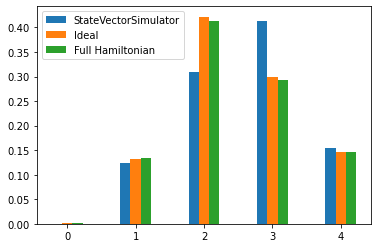

In [185]:
plt.bar(np.array(range(n+1))-0.15, dist, width=0.15, label=f"{device.name}")
plt.bar(np.array(range(n+1)), ideal_dist, width=0.15, label="Ideal")
plt.bar(np.array(range(n+1))+0.15, sim_dist, width=0.15, label="Full Hamiltonian")
plt.legend()
plt.show()